In [4]:
import sys
sys.path[:3]


['c:\\kworld\\AI_World\\CDO-Innovation-Hub\\Data-Science\\01-executive-anomaly-detection',
 'C:\\Software\\anaconda3\\python313.zip',
 'C:\\Software\\anaconda3\\DLLs']

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project folder
FIGURES_DIR = Path("../outputs/figures")
TABLES_DIR = Path("../outputs/tables")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
from src.data_loader import load_yellow_taxi_data
from src.anomaly_utils import rolling_anomaly_scores

plt.style.use("default")

print(PROJECT_ROOT)
print(FIGURES_DIR)
print(TABLES_DIR)


c:\kworld\AI_World\CDO-Innovation-Hub\Data-Science\01-executive-anomaly-detection
..\outputs\figures
..\outputs\tables


In [ ]:
'''DATA_PATH = Path("../data/raw/yellow_tripdata_2019-01.parquet")

print(DATA_PATH)

df = pd.read_parquet(DATA_PATH)

df.head()
'''

..\data\raw\yellow_tripdata_2019-01.parquet


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN,None
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN,None
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN,None
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN,None
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN,None


In [5]:
RAW_DATA_DIR = Path("../data/raw")

df = load_yellow_taxi_data(
    raw_data_dir=RAW_DATA_DIR,
    columns=["tpep_pickup_datetime"]
)

df.head(), df.shape


Loading the following files:
 - yellow_tripdata_2019-01.parquet
 - yellow_tripdata_2019-02.parquet
 - yellow_tripdata_2019-03.parquet
 - yellow_tripdata_2019-04.parquet
 - yellow_tripdata_2019-05.parquet
 - yellow_tripdata_2019-06.parquet

Total rows loaded: 44,658,561


(  tpep_pickup_datetime
 0  2019-01-01 00:46:40
 1  2019-01-01 00:59:47
 2  2018-12-21 13:48:30
 3  2018-11-28 15:52:25
 4  2018-11-28 15:56:57,
 (44658561, 1))

In [6]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

print("Data coverage:")
print("Start:", df["tpep_pickup_datetime"].min())
print("End  :", df["tpep_pickup_datetime"].max())
print("Unique days:", df["tpep_pickup_datetime"].dt.date.nunique())
print("Rows :", len(df))


Data coverage:
Start: 2001-01-01 00:02:08
End  : 2088-01-24 00:25:39
Unique days: 246
Rows : 44658561


In [8]:
# Ensure datetime
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

# Aggregate to daily trip counts
daily_trips = (
    df
    .assign(date=df["tpep_pickup_datetime"].dt.date)
    .groupby("date")
    .size()
    .reset_index(name="daily_trips")
)

daily_trips["date"] = pd.to_datetime(daily_trips["date"])

daily_trips.head()


,date,daily_trips
0,2001-01-01,2
1,2001-02-02,1
2,2002-12-31,2
3,2003-01-01,2
4,2008-08-08,3


In [10]:
#daily_trips = daily_trips[    (daily_trips["date"] >= "2019-01-01") &     (daily_trips["date"] <= "2019-01-31")]



results = rolling_anomaly_scores(
    df=daily_trips,
    date_col="date",
    value_col="daily_trips",
    window=21,
    z_threshold=3.0
)

results.head()


,date,daily_trips,baseline_mean,baseline_std,z_score,is_anomaly
0,2001-01-01,2,NaN,NaN,NaN,False
1,2001-02-02,1,NaN,NaN,NaN,False
2,2002-12-31,2,NaN,NaN,NaN,False
3,2003-01-01,2,NaN,NaN,NaN,False
4,2008-08-08,3,NaN,NaN,NaN,False


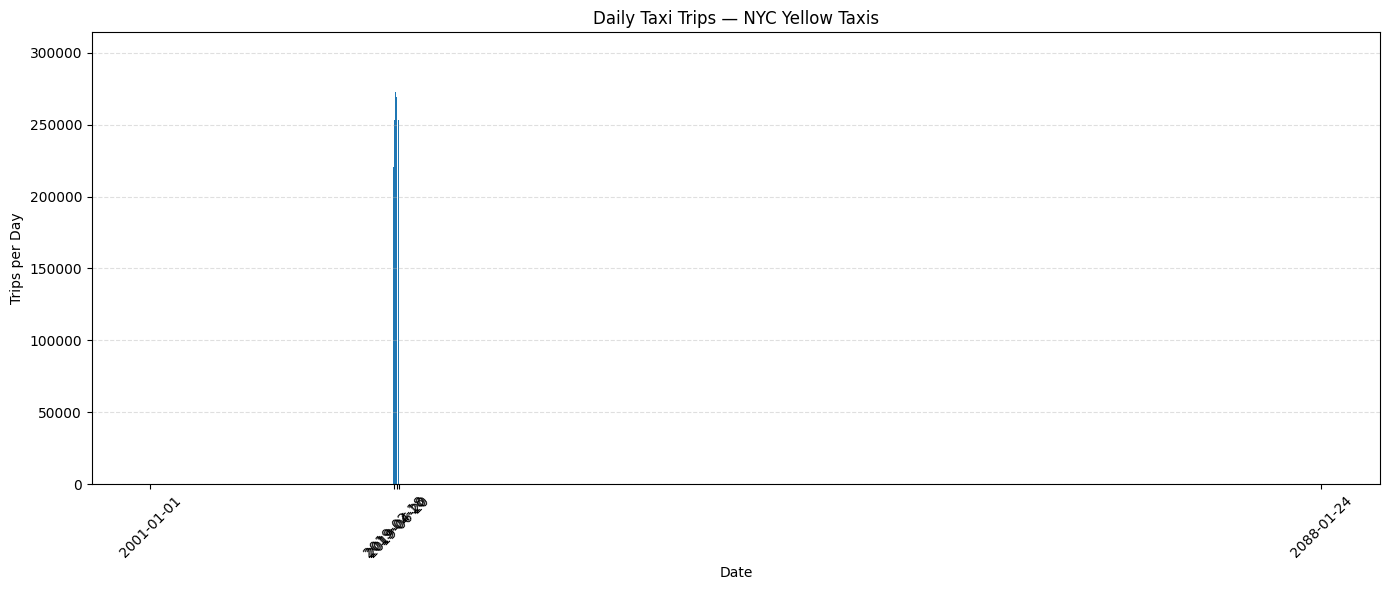

In [18]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    daily_trips["date"],
    daily_trips["daily_trips"]
)

ax.set_title("Daily Taxi Trips — NYC Yellow Taxis")
ax.set_xlabel("Date")
ax.set_ylabel("Trips per Day")

# 👇 Reduce x-axis labels to ~5
tick_positions = np.linspace(
    0, len(daily_trips) - 1, 5, dtype=int
)

ax.set_xticks(daily_trips["date"].iloc[tick_positions])
ax.tick_params(axis="x", rotation=45)

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "daily_trips_bar_chart_5_ticks.png", dpi=150)
plt.show()


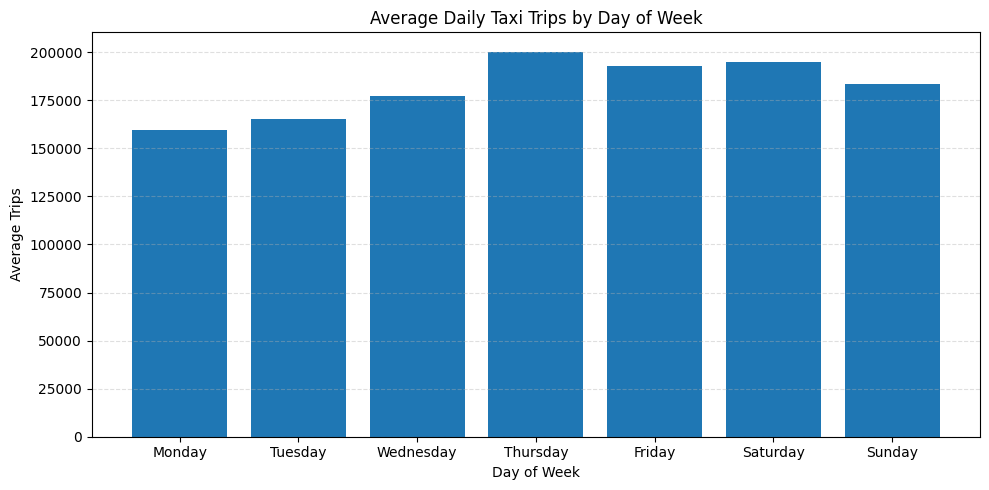

In [19]:
daily_trips["day_of_week"] = daily_trips["date"].dt.day_name()

dow_summary = (
    daily_trips
    .groupby("day_of_week")["daily_trips"]
    .mean()
    .reindex([
        "Monday","Tuesday","Wednesday",
        "Thursday","Friday","Saturday","Sunday"
    ])
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dow_summary.index, dow_summary.values)

ax.set_title("Average Daily Taxi Trips by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Trips")

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "avg_trips_by_day_of_week.png", dpi=150)
plt.show()


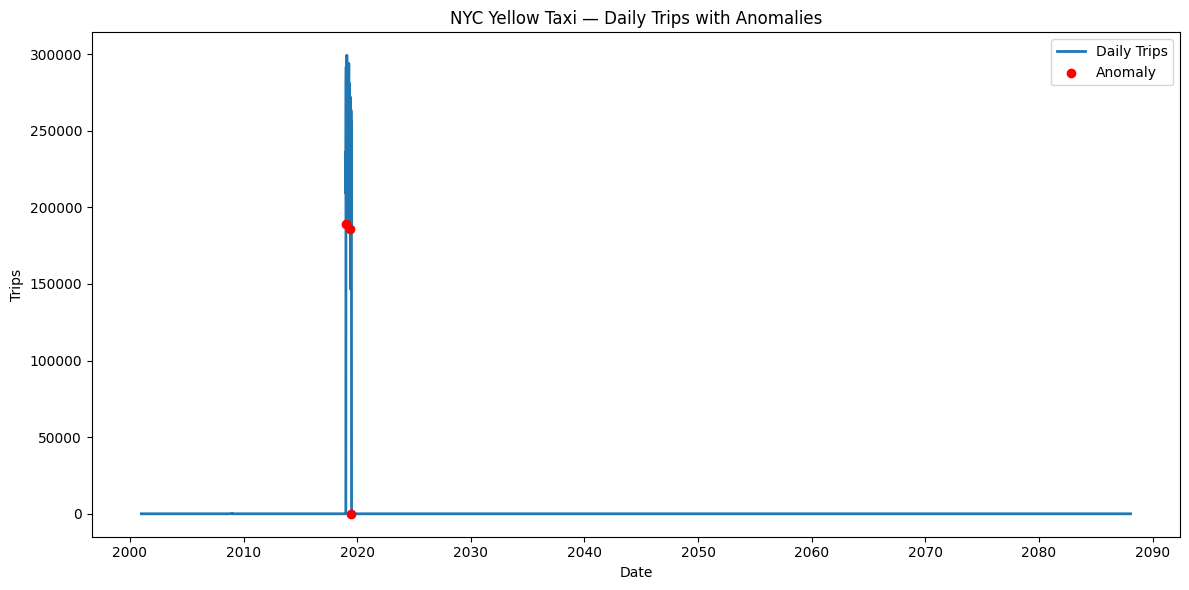

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(results["date"], results["daily_trips"], label="Daily Trips", linewidth=2)

anomalies = results[results["is_anomaly"]]
ax.scatter(
    anomalies["date"],
    anomalies["daily_trips"],
    color="red",
    label="Anomaly",
    zorder=5
)

ax.set_title("NYC Yellow Taxi — Daily Trips with Anomalies")
ax.set_xlabel("Date")
ax.set_ylabel("Trips")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR /"daily_trips_anomalies.png", dpi=150)
plt.show()


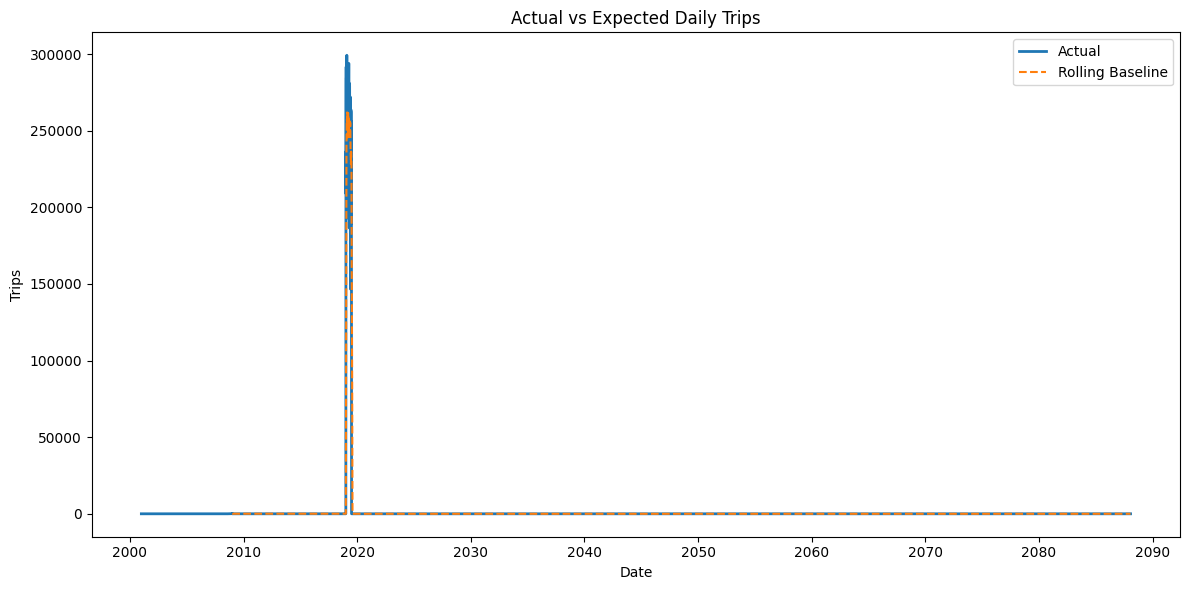

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(results["date"], results["daily_trips"], label="Actual", linewidth=2)
ax.plot(results["date"], results["baseline_mean"], label="Rolling Baseline", linestyle="--")

ax.set_title("Actual vs Expected Daily Trips")
ax.set_xlabel("Date")
ax.set_ylabel("Trips")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_vs_actual.png", dpi=150)
plt.show()


In [13]:
top_anomalies = (
    results
    .loc[results["is_anomaly"]]
    .assign(severity=lambda x: x["z_score"].abs())
    .sort_values("severity", ascending=False)
    .head(10)
)

OUTPUT_PATH = Path("../outputs/tables")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

top_anomalies.to_csv(OUTPUT_PATH / "top_anomalies.csv", index=False)

top_anomalies


,date,daily_trips,baseline_mean,baseline_std,z_score,is_anomaly,severity
194,2019-07-01,26,221236.523810,54854.733966,-4.032661,True,4.032661
13,2019-01-01,189432,13583.071429,48771.829919,3.605543,True,3.605543
157,2019-05-25,185731,247767.380952,20207.449860,-3.069976,True,3.069976


In [14]:
MIN_BASELINE = 1000

top_unusual = (
    results
    .dropna(subset=["z_score"])
    .assign(
        severity=lambda x: x["z_score"].abs(),
        direction=lambda x: np.where(   x["baseline_mean"] < MIN_BASELINE,"Low-volume noise",np.where(x["z_score"] >= 0, "Spike", "Drop")    )
        #direction=lambda x: np.where(x["z_score"] >= 0, "Spike", "Drop")
    )
    .sort_values("severity", ascending=False)
    .head(10)
)

top_unusual.to_csv(TABLES_DIR / "top_unusual_observations.csv", index=False)
top_unusual
# Debugging: check outputs

,date,daily_trips,baseline_mean,baseline_std,z_score,is_anomaly,severity,direction
194,2019-07-01,26,221236.523810,54854.733966,-4.032661,True,4.032661,Drop
13,2019-01-01,189432,13583.071429,48771.829919,3.605543,True,3.605543,Spike
157,2019-05-25,185731,247767.380952,20207.449860,-3.069976,True,3.069976,Drop
158,2019-05-26,165205,244306.714286,26763.895197,-2.955538,False,2.955538,Drop
195,2019-07-02,2,209762.857143,72038.834055,-2.911775,False,2.911775,Drop
159,2019-05-27,146701,240389.761905,33814.266295,-2.770687,False,2.770687,Drop
193,2019-06-30,167833,231813.000000,23812.247569,-2.686853,False,2.686853,Drop
12,2018-12-31,345,56.230769,108.625789,2.658386,False,2.658386,Low-volume noise
14,2019-01-02,198737,25926.666667,65978.881280,2.619176,False,2.619176,Spike
123,2019-04-21,186538,252438.095238,25177.915846,-2.617377,False,2.617377,Drop


In [15]:
# DEbugging: check outputs

results[["daily_trips","baseline_mean","baseline_std","z_score","is_anomaly"]].tail(10)

print("Rows:", len(results))
print("Anomalies flagged:", results["is_anomaly"].sum())
print("z_score stats:\n", results["z_score"].describe())
print("baseline_std nulls:", results["baseline_std"].isna().sum())
results.info()

Rows: 246
Anomalies flagged: 3
z_score stats:
 count    240.000000
mean      -0.042755
std        1.141540
min       -4.032661
25%       -0.780048
50%        0.032776
75%        0.698014
max        3.605543
Name: z_score, dtype: float64
baseline_std nulls: 6
<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype        
---  ------         --------------  -----        
 0   date           246 non-null    datetime64[s]
 1   daily_trips    246 non-null    int64        
 2   baseline_mean  240 non-null    float64      
 3   baseline_std   240 non-null    float64      
 4   z_score        240 non-null    float64      
 5   is_anomaly     246 non-null    bool         
dtypes: bool(1), datetime64[s](1), float64(3), int64(1)
memory usage: 10.0 KB
